In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [5]:
['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE','Q_Base_ET_KGE', 'Q_B_ET_KGE', 'Q_ET_DA_ET_KGE']

['Q_Base_Q_KGE',
 'Q_B_Q_KGE',
 'Q_ET_DA_Q_KGE',
 'Q_Base_ET_KGE',
 'Q_B_ET_KGE',
 'Q_ET_DA_ET_KGE']

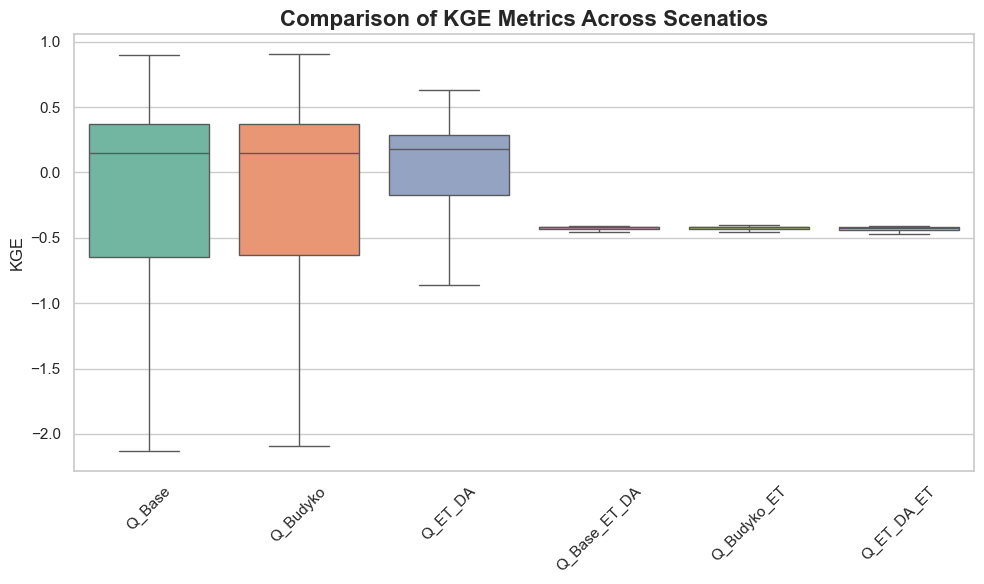

In [35]:

df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_performance_metrics.csv')
df = df.dropna()
# df.set_index('basin_id', inplace=True)
df.describe()

kge_cols = ['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE','Q_Base_ET_KGE', 'Q_B_ET_KGE', 'Q_ET_DA_ET_KGE']

xtick_labels = ['Q_Base', 'Q_Budyko', 'Q_ET_DA', 'Q_Base_ET_DA', 'Q_Budyko_ET', 'Q_ET_DA_ET']

df_clean = df[kge_cols].replace([np.inf, -np.inf], np.nan).dropna()

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, palette="Set2", showfliers=False)
plt.xticks(ticks=range(len(xtick_labels)), labels=xtick_labels, rotation=45, fontsize=11)
plt.title("Comparison of KGE Metrics Across Scenatios", fontsize=16, fontweight='bold')
plt.ylabel("KGE", fontsize=12)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()



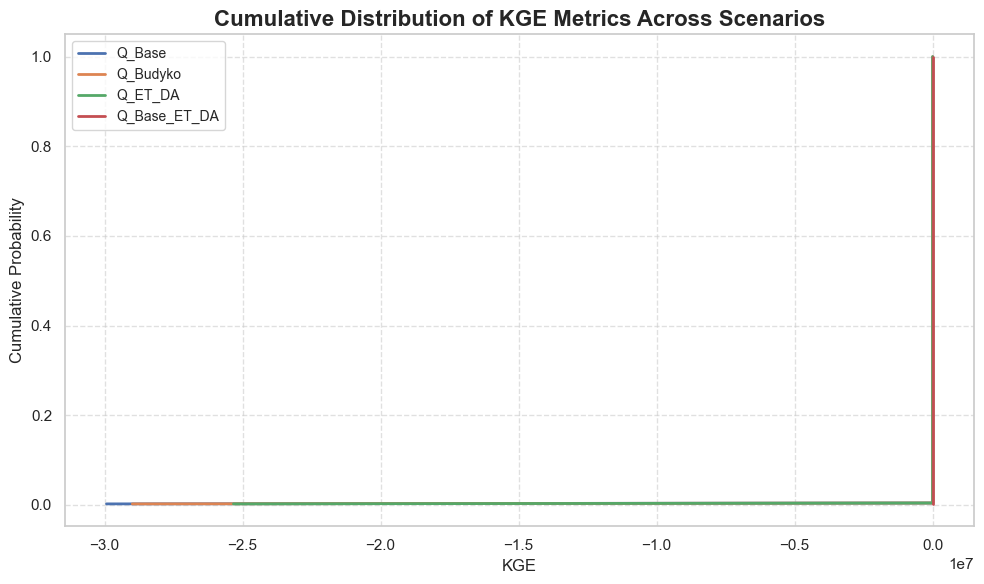

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_performance_metrics.csv')
df = df.dropna()
# df.set_index('basin_id', inplace=True)

kge_cols = ['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE','Q_Base_ET_KGE']#, 'Q_B_ET_KGE', 'Q_ET_DA_ET_KGE']
xtick_labels = ['Q_Base', 'Q_Budyko', 'Q_ET_DA', 'Q_Base_ET_DA']#, 'Q_Budyko_ET', 'Q_ET_DA_ET']

df_clean = df[kge_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Plot CDF
plt.figure(figsize=(10,6))
for col, label in zip(kge_cols, xtick_labels):
    sorted_data = np.sort(df_clean[col])
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, linewidth=2)

plt.title("Cumulative Distribution of KGE Metrics Across Scenarios", fontsize=16, fontweight='bold')
plt.xlabel("KGE", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
# plt.xlim(-5, 1)
# plt.ylim(0.15, 1)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [8]:
max_value = df_clean['Q_B_Q_KGE'].max()
max_index = df_clean['Q_B_Q_KGE'].idxmax()

print("Maximum value:", max_value)
print("Index of maximum value:", max_index)


Maximum value: 0.8639
Index of maximum value: 11532500


In [9]:
top5 = df_clean['Q_B_Q_KGE'].nlargest(7)
print(top5)


basin_id
11532500    0.8639
14301000    0.7438
6043500     0.5719
5412500     0.5248
7071500     0.4719
11528700    0.4702
6191500     0.3938
Name: Q_B_Q_KGE, dtype: float64


# hydrograph of '11522500':

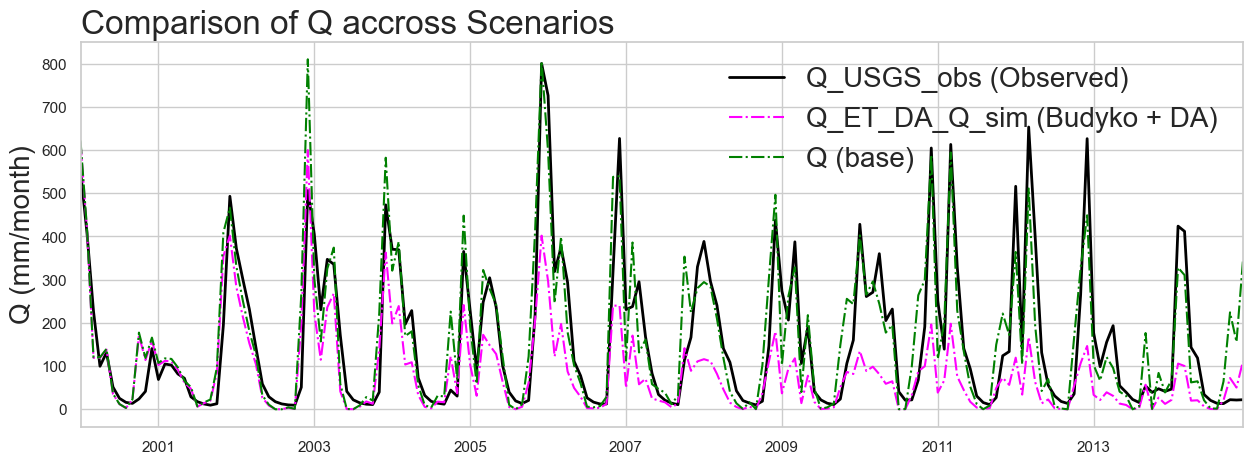

In [41]:

file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\11532500_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    df = pd.read_feather(file_path)
    df.set_index('Date', inplace=True)
    plt.figure(figsize=(15, 5)) #, dpi=200
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='black', lw=2)
    df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='magenta', linestyle='-.')
    # df['Q_B_Q_sim'].plot(label='Q (from ET_Budyko)', color='magenta', linestyle='-.')
    df['Q_Base_Q_sim'].plot(label='Q (base)', color='green', linestyle='-.')


    plt.xlabel('')
    plt.ylabel('Q (mm/month)',fontsize=20)
    plt.title('Comparison of Q accross Scenarios',fontsize=24, loc='left')
    plt.legend(fontsize=20, frameon=False)
    plt.grid(True)
    plt.show()

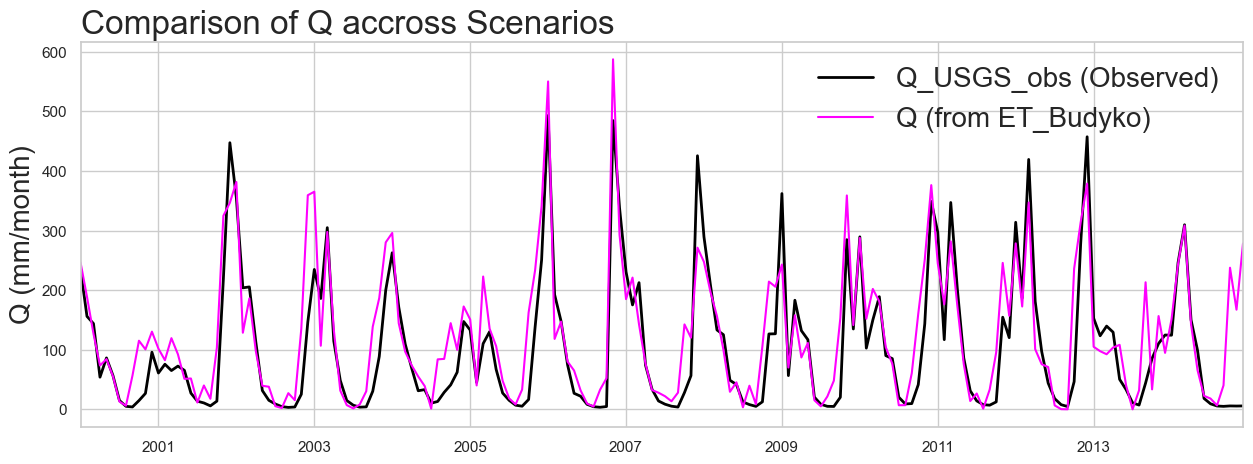

In [12]:

file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\14301000_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    df = pd.read_feather(file_path)
    df.set_index('Date', inplace=True)
    plt.figure(figsize=(15, 5))
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='black', lw=2)
    # df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='magenta', linestyle='-.')
    df['Q_B_Q_sim'].plot(label='Q (from ET_Budyko)', color='magenta')
    # df['Q_Base_Q_sim'].plot(label='Q (base)', color='green', linestyle='-.')


    plt.xlabel('')
    plt.ylabel('Q (mm/month)',fontsize=20)
    plt.title('Comparison of Q accross Scenarios',fontsize=24, loc='left')
    plt.legend(fontsize=20, frameon=False)
    plt.grid(True)
    plt.show()

In [13]:
data_dir = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin"

ML_data_prepared_all_1960_1980_dairy = pd.read_feather(os.path.join(data_dir, "14301000_enkf_timeseries_ET_DA.feather"))
ML_data_prepared_all_1960_1980_dairy

,Date,P_input,PET_input,Q_USGS_obs,Q_NLDAS_input,ET_NLDAS_obs,ET_Budyko,Q_Base_Q_sim,Q_Base_ET_sim,Q_Base_S_sim,Q_Base_G_sim,Q_B_Q_sim,Q_B_ET_sim,Q_B_S_sim,Q_B_G_sim,Q_ET_DA_Q_sim,Q_ET_DA_ET_sim,Q_ET_DA_S_sim,Q_ET_DA_G_sim
0,2000-01-01,274.780060,0.034365,235.278407,644.613281,16.688271,0.033269,249.004460,0.021650,0.0,0.0,246.818228,0.031273,0.0,0.0,246.816761,0.022883,0.0,0.0
1,2000-02-01,220.942551,0.051716,156.024370,628.874268,20.941240,0.049663,190.616622,0.032582,0.0,0.0,188.833025,0.046683,0.0,0.0,188.782169,0.034283,0.0,0.0
2,2000-03-01,148.359711,0.105238,143.942619,628.676941,34.793049,0.099077,127.992340,0.066301,0.0,0.0,126.801536,0.093133,0.0,0.0,126.655000,0.068365,0.0,0.0
3,2000-04-01,86.058174,0.172558,54.008651,588.033142,35.286480,0.158025,74.238227,0.108713,0.0,0.0,73.556147,0.148544,0.0,0.0,73.346278,0.110891,0.0,0.0
4,2000-05-01,98.675308,0.203617,86.289797,589.214539,49.614380,0.186296,85.123290,0.128281,0.0,0.0,84.337767,0.175118,0.0,0.0,83.898533,0.129582,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2014-08-01,7.717692,0.236031,5.619908,492.879211,40.908138,0.184502,6.646225,0.146484,0.0,0.0,6.605068,0.170573,0.0,0.0,2.185096,0.142641,0.0,0.0
176,2014-09-01,47.092388,0.213956,5.030555,464.288300,37.711246,0.189966,40.618357,0.134604,0.0,0.0,40.254613,0.178199,0.0,0.0,13.448548,0.129301,0.0,0.0
177,2014-10-01,278.069336,0.115640,5.735774,535.574890,34.248959,0.110024,239.902921,0.072854,0.0,0.0,237.651627,0.103422,0.0,0.0,79.545585,0.069885,0.0,0.0
178,2014-11-01,195.708878,0.053797,5.550749,627.531189,18.583261,0.051537,168.845472,0.033893,0.0,0.0,167.268132,0.048445,0.0,0.0,55.981594,0.032511,0.0,0.0


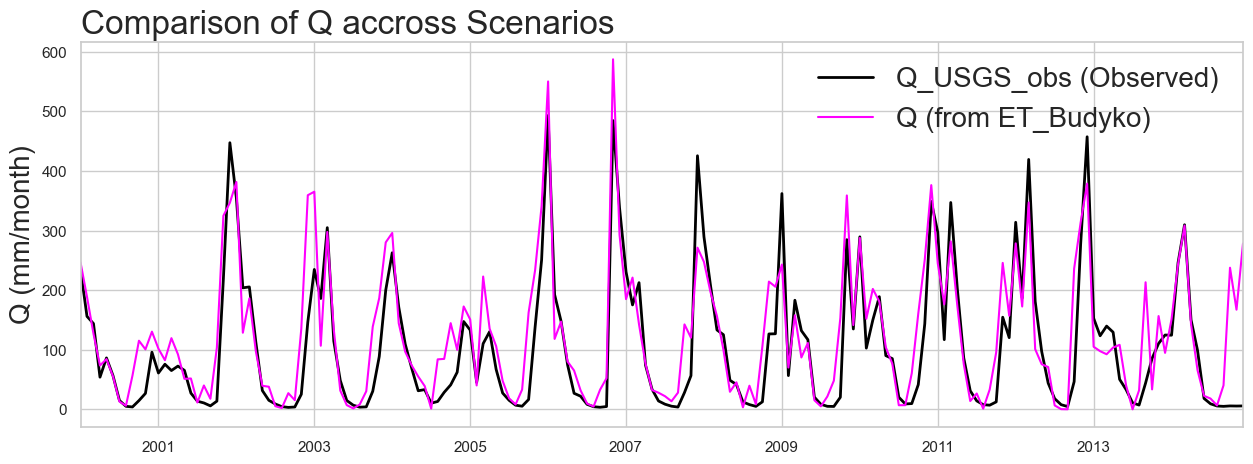

In [14]:

file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\14301000_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    df = pd.read_feather(file_path)
    df.set_index('Date', inplace=True)
    plt.figure(figsize=(15, 5))
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='black', lw=2)
    # df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='magenta', linestyle='-.')
    df['Q_B_Q_sim'].plot(label='Q (from ET_Budyko)', color='magenta')
    # df['Q_Base_Q_sim'].plot(label='Q (base)', color='green', linestyle='-.')


    plt.xlabel('')
    plt.ylabel('Q (mm/month)',fontsize=20)
    plt.title('Comparison of Q accross Scenarios',fontsize=24, loc='left')
    plt.legend(fontsize=20, frameon=False)
    plt.grid(True)
    plt.show()

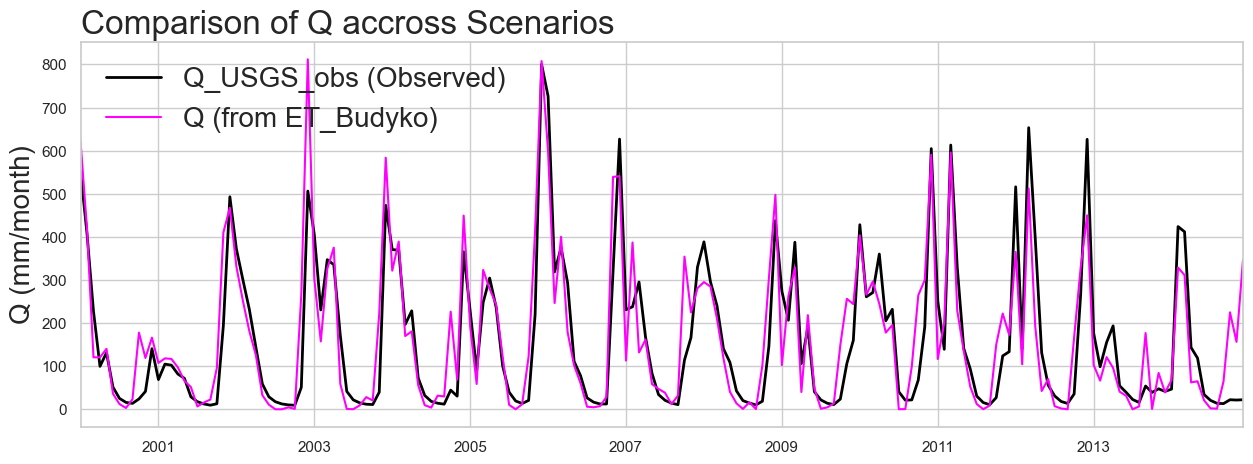

In [15]:

file_path = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries_by_basin\11532500_enkf_timeseries_ET_DA.feather"

if not os.path.exists(file_path):
    print("Error: Feather file not found. Check path.")
else:
    df = pd.read_feather(file_path)
    df.set_index('Date', inplace=True)
    plt.figure(figsize=(15, 5))
    df['Q_USGS_obs'].plot(label='Q_USGS_obs (Observed)', color='black', lw=2)
    # df['Q_ET_DA_Q_sim'].plot(label='Q_ET_DA_Q_sim (Budyko + DA)', color='magenta', linestyle='-.')
    df['Q_B_Q_sim'].plot(label='Q (from ET_Budyko)', color='magenta')
    # df['Q_Base_Q_sim'].plot(label='Q (base)', color='green', linestyle='-.')


    plt.xlabel('')
    plt.ylabel('Q (mm/month)',fontsize=20)
    plt.title('Comparison of Q accross Scenarios',fontsize=24, loc='left')
    plt.legend(fontsize=20, frameon=False)
    plt.grid(True)
    plt.show()

In [28]:
data_dir = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\data\processed"
extracted_nldas_data2 = pd.read_feather(os.path.join(data_dir, "PotEvap.feather"))
extracted_nldas_data2.columns#()#dropna(axis=1)

Index(['time', '06452000', '13340000', '06447000', '06360500', '06354000',
       '05057000', '07301500', '06191500', '02315500',
       ...
       '09378630', '01118300', '02381600', '01434025', '01484100', '06746095',
       '14303200', '03357350', '01466500', '06614800'],
      dtype='object', length=608)

In [18]:
import numpy as np
from src.budyko import solve_omega_true, fit_omega_mlr, estimate_budyko_et

# Example: TARGET_BASINS list
TARGET_BASINS = list(Evap_df.columns)

# Dictionary to store Budyko ET results
budyko_ET_results = {}

for basin in TARGET_BASINS:
    # --- Extract inputs per basin ---
    P_arr = Rainf_df[basin].values          # Precipitation (mm)
    PET_arr = PotEvap_df[basin].values      # Potential ET (mm)
    ET_obs_arr = Evap_df[basin].values      # Observed ET (mm)
    
    # Vegetation fraction (M) and slope from attributes (assume single value per basin)
    M_val = attrs.loc[basin, 'forest_fraction']  # or any suitable vegetation fraction
    Slope_val = attrs.loc[basin, 'slope_mean']   # mean slope in degrees
    
    # --- Step 1: Solve for omega_true ---
    # For Budyko omega, Qb_obs is not needed if you only care about ET modeling
    omega_true = solve_omega_true(P=P_arr, PET=PET_arr, ET_obs=ET_obs_arr, Qb_obs=np.zeros_like(P_arr))
    
    # --- Step 2: Fit Omega MLR model ---
    M_arr = np.full_like(omega_true, M_val)
    Slope_arr = np.full_like(omega_true, Slope_val)
    omega_model = fit_omega_mlr(M=M_arr, Slope=Slope_arr, omega_true=omega_true)
    
    # --- Step 3: Estimate Budyko ET ---
    ET_budyko = np.array([
        estimate_budyko_et(P=P_arr[i],
                           PET=PET_arr[i],
                           M=M_arr[i],
                           Slope=Slope_arr[i],
                           omega_model=omega_model)
        for i in range(len(P_arr))
    ])
    
    # --- Save results ---
    budyko_ET_results[basin] = ET_budyko

# Example: convert to DataFrame
import pandas as pd
budyko_ET_df = pd.DataFrame(budyko_ET_results, index=Rainf_df.index)
print(budyko_ET_df.head())


ModuleNotFoundError: No module named 'src'